In [1]:
source("../R/shared_data.R")
library(MASS)      # pour lda()
library(tidyverse)
library(ggplot2)
select <- dplyr::select  # ← règle le conflit MASS vs dplyr

df <- load_analysis_data()


Warning message:
"le package 'tidyverse' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'tibble' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'readr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'stringr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'forcats' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'lubridate' a été compilé avec la version R 4.4.3"

Attachement du package : 'MASS'


L'objet suivant est masqué depuis 'package:dplyr':

    select




In [2]:
var_quanti <- names(df)[sapply(df, is.numeric)]

df_lda <- df %>%
  select(all_of(var_quanti), "Filière.de.formation.très.agrégée") %>%
  rename(filiere = "Filière.de.formation.très.agrégée")

Pour plus de simplicité, on merge certaines formations similaires

In [3]:
df_lda %>% count(filiere, sort = TRUE)

filiere,n
<fct>,<int>
BTS,5351
Licence,3052
Autre formation,1815
CPGE,986
BUT,820
Ecole d'Ingénieur,585
Licence_Las,513
IFSI,344
PASS,287


On peut éventuellement recoder la variable pour simplifier, on le fait pas pour le moment

In [ ]:
# library(forcats)

# df_lda <- df_lda %>%
#   mutate(filiere = fct_recode(filiere,
#     "Licence"  = "Licence",   # merge ces deux ensemble
#     "Licence"    = "Licence générale",
#     "Licence"    = "Licence professionnelle",   # merge
#     "CPGE"       = "Classe préparatoire",
#     ...
#   ))

In [4]:
modele_lda <- lda(filiere ~ ., data = df_lda)
modele_lda

Warning message in lda.default(x, grouping, ...):
"les variables sont colinéaires"


Call:
lda(filiere ~ ., data = df_lda)

Prior probabilities of groups:
  Autre formation               BTS               BUT              CPGE 
       0.12735055        0.37545608        0.05753578        0.06918327 
Ecole d'Ingénieur Ecole de Commerce              EFTS              IFSI 
       0.04104687        0.01796239        0.01705024        0.02413696 
          Licence       Licence_Las              PASS 
       0.21414538        0.03599495        0.02013752 

Group means:
                  Capacité.de.l.établissement.par.formation
Autre formation                                    27.45675
BTS                                                31.58905
BUT                                                72.26220
CPGE                                               47.44828
Ecole d'Ingénieur                                  44.98803
Ecole de Commerce                                  89.32812
EFTS                                               31.65844
IFSI                              

In [5]:
prop_variance <- modele_lda$svd^2 / sum(modele_lda$svd^2)
round(prop_variance * 100, 1)

[1] 53.6 14.0 10.2  8.5  5.3  2.9  2.2  1.5  0.9  0.8

In [6]:
predictions <- predict(modele_lda)

df_plot <- data.frame(
  LD1 = predictions$x[, 1],
  LD2 = predictions$x[, 2],
  filiere = df_lda$filiere
)

head(df_plot)

,LD1,LD2,filiere
,<dbl>,<dbl>,<fct>
1,1.07024665,1.2454418,Autre formation
2,-0.71943873,0.6953160,Licence
3,-0.58215372,-0.7914153,IFSI
4,2.04917547,-0.7248171,PASS
5,2.21122068,-1.3224376,PASS
6,-0.01128276,0.1234751,Licence


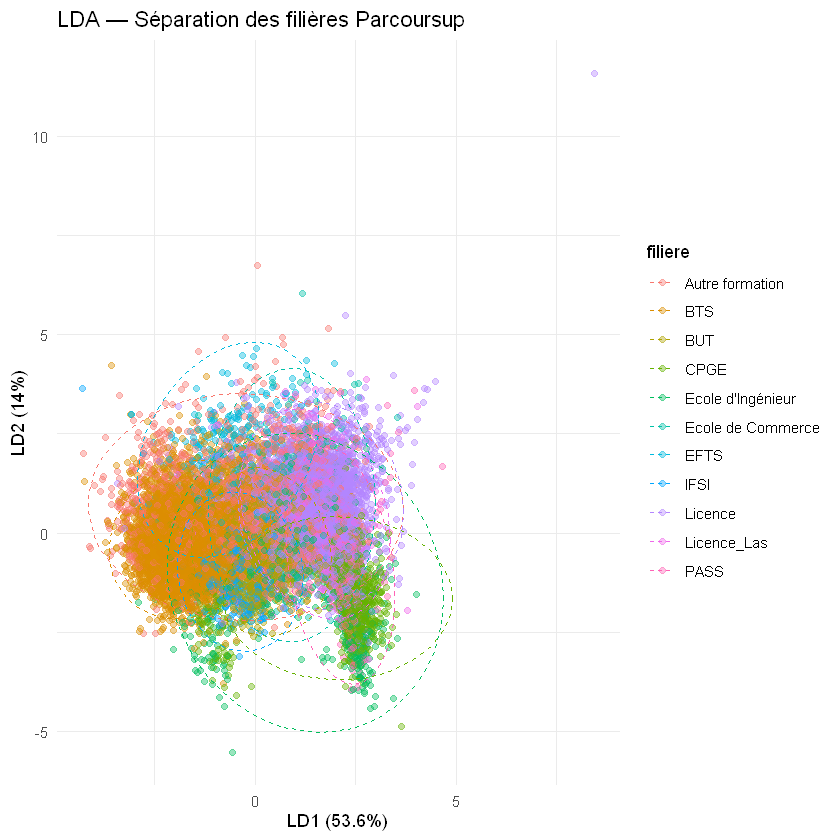

In [7]:
ggplot(df_plot, aes(x = LD1, y = LD2, color = filiere)) +
  geom_point(alpha = 0.4, size = 1.5) +
  stat_ellipse(aes(group = filiere), type = "norm", linetype = "dashed") +
  labs(
    title = "LDA — Séparation des filières Parcoursup",
    x = paste0("LD1 (", round(prop_variance[1] * 100, 1), "%)"),
    y = paste0("LD2 (", round(prop_variance[2] * 100, 1), "%)")
  ) +
  theme_minimal()

In [8]:
predictions_class <- predictions$class

table(Réel = df_lda$filiere, Prédit = predictions_class)

# Taux de bonne classification global
mean(predictions_class == df_lda$filiere)

                   Prédit
Réel               Autre formation  BTS  BUT CPGE Ecole d'Ingénieur
  Autre formation               556  580   66   87                56
  BTS                           191 4931   19    2                39
  BUT                            57   77  493    7                 4
  CPGE                            7   64   41  710                22
  Ecole d'Ingénieur              47   40   31   77               196
  Ecole de Commerce              22    4   18    2                11
  EFTS                           35   53    0    0                 6
  IFSI                            2   75   11    0                 0
  Licence                       121   91   30  239                40
  Licence_Las                    29   12    5   23                 5
  PASS                            0    0    0   40                 3
                   Prédit
Réel               Ecole de Commerce EFTS IFSI Licence Licence_Las PASS
  Autre formation                  37   69    7  

[1] 0.6970951

LDA compliquée à visualiser avec autant de classes : on en retente une en regroupant les modalités par secteur

In [10]:
library(forcats)

df_lda_simple <- df_lda %>%
  filter(filiere != "Autre formation") %>%
  mutate(filiere = fct_recode(filiere,
    "Santé"  = "PASS",   # merge ces deux ensemble
    "Santé"    = "Licence_Las", 
    "Santé"    = "IFSI",
    "BUT/BTS"       = "BUT", 
    "BUT/BTS"       = "BTS",
    "BUT/BTS"       = "EFTS",
    "Licence"  = "Licence", 
    "Grande école" = "CPGE",
    "Grande école" = "Ecole de Commerce",
    "Grande école" = "Ecole d'Ingénieur"

    
  ))

In [11]:
modele_lda_simple <- lda(filiere ~ ., data = df_lda_simple)
modele_lda_simple

Warning message in lda.default(x, grouping, ...):
"le groupe Autre formation est vide"
Warning message in lda.default(x, grouping, ...):
"les variables sont colinéaires"


Call:
lda(filiere ~ ., data = df_lda_simple)

Prior probabilities of groups:
     BUT/BTS Grande école        Santé      Licence 
   0.5157192    0.1469004    0.0919836    0.2453968 

Group means:
             Capacité.de.l.établissement.par.formation
BUT/BTS                                       36.79155
Grande école                                  52.52874
Santé                                         68.59790
Licence                                      101.27457
             Effectif.total.admis.2phases Effectif.total.candidats.2phases
BUT/BTS                          28.19255                         562.4994
Grande école                     42.98358                        1448.3103
Santé                            67.73776                        2677.5743
Licence                          92.44528                        1088.2231
             Pourcentage.boursiers.candidats Pourcentage.boursiers.admis
BUT/BTS                             25.06506                    26.80695
Grande 

In [12]:
prop_variance <- modele_lda_simple$svd^2 / sum(modele_lda_simple$svd^2)
round(prop_variance * 100, 1)

[1] 74.1 17.2  8.7

In [14]:
predictions_simple <- predict(modele_lda_simple)

df_plot_simple <- data.frame(
  LD1 = predictions_simple$x[, 1],
  LD2 = predictions_simple$x[, 2],
  filiere = df_lda_simple$filiere
)

head(df_plot_simple)

,LD1,LD2,filiere
,<dbl>,<dbl>,<fct>
1,-0.45190518,1.48419191,Licence
2,-0.45849311,0.02569147,Santé
3,1.96674467,0.24323973,Santé
4,2.28226626,-0.66266382,Santé
5,0.08829456,0.82903046,Licence
6,1.27892227,1.48690094,Santé


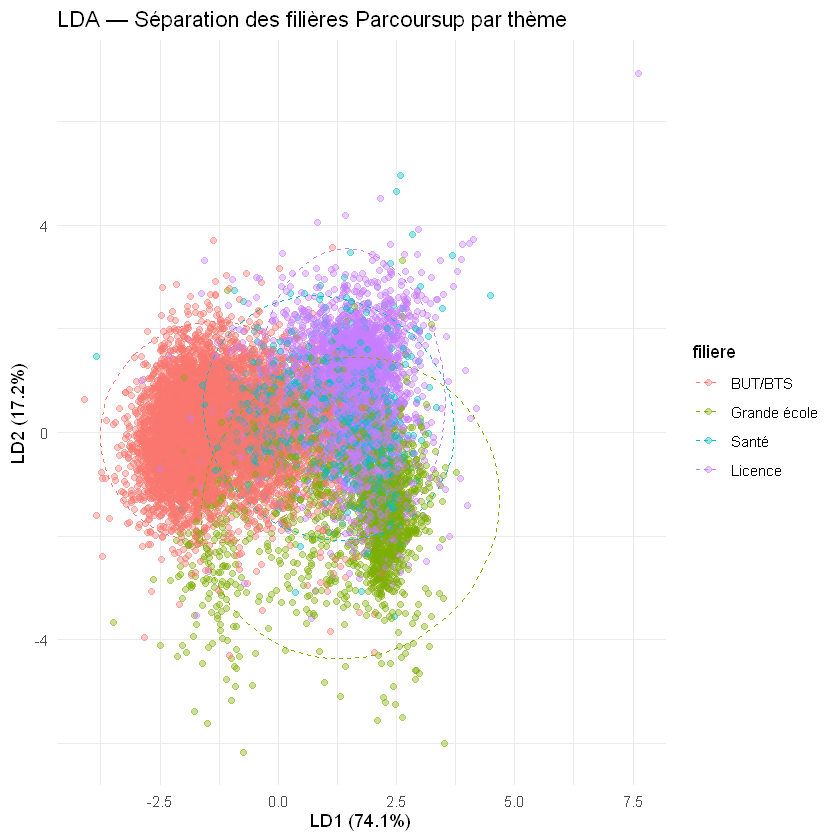

In [15]:
ggplot(df_plot_simple, aes(x = LD1, y = LD2, color = filiere)) +
  geom_point(alpha = 0.4, size = 1.5) +
  stat_ellipse(aes(group = filiere), type = "norm", linetype = "dashed") +
  labs(
    title = "LDA — Séparation des filières Parcoursup par thème",
    x = paste0("LD1 (", round(prop_variance[1] * 100, 1), "%)"),
    y = paste0("LD2 (", round(prop_variance[2] * 100, 1), "%)")
  ) +
  theme_minimal()

Commentaire : ça donne pas grand chose...